# Le robot agit


## Comment le robot se déplace ?
Il peut tourner autour de lui-même et il peut avancer tout droit. C'est le modèle le plus simple et ça permet d'atteindre n'importe quel point d'un plan.

In [2]:
from slam_robot.models.robot import Robot
from slam_robot.utils.geometry import Point

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (5, 5)

In [19]:
def reinit_robot():
    initial_position = Point(12, 12)
    initial_orientation = 0
    robot = Robot(initial_position, initial_orientation)
    return robot

In [20]:
robot = reinit_robot()

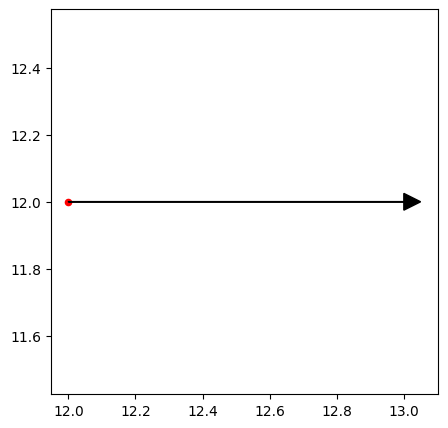

In [4]:
ax = plt.axes()
robot.draw(ax, with_orientation=True)
plt.show()

Et si le robot avançait ? La fonction pour faire avancer le robot est `Robot.move(duration)`. Regardons ce qui s'est passé. 

In [5]:
robot.move(10) # la durée est en secondes

Point(13.0, 12.0)

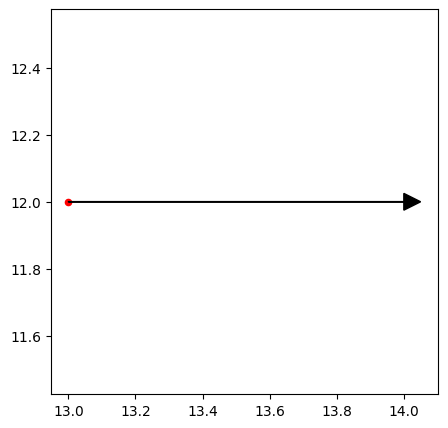

In [6]:
ax = plt.axes()
robot.draw(ax, with_orientation=True)
plt.show()

On voit que le robot s'est déplacé dans la direction de la flèche. Mais de combien s'est-il déplacé ? Il s'est à peine déplacé d'1 cm en 10 secondes. En fait, le déplacement de distance $d$ dépend de la vitesse de déplacement $\vec{v}$, qui est un paramètre du robot, et de la durée de déplacement $t$, qui est aussi un paramètre. Par définition, on a $d = \|\vec{v}\| * t$. C'est le modèle le plus simple où la vitesse est constante. La réalité est bien différente.

Par défaut, la vitesse est de `Robot.velocity`.

In [7]:
robot.velocity

0.1

On peut redéfinir la vitesse par `Robot.set_velocity(velocity)`.

In [8]:
robot.set_velocity(0.3)  # la vitesse est en mètre par seconde.

Le robot peut aussi tourner autour de lui-même. Là aussi, la rotation dépend de la vitesse de rotation et de la durée de rotation.



In [9]:
robot.rotation_velocity

0.1

In [10]:
robot.set_rotation_velocity(0.3)  # la vitesse de rotation est en radian par seconde.

In [11]:
import numpy as np
robot.turn(np.pi / 3)

0.31415926535897926

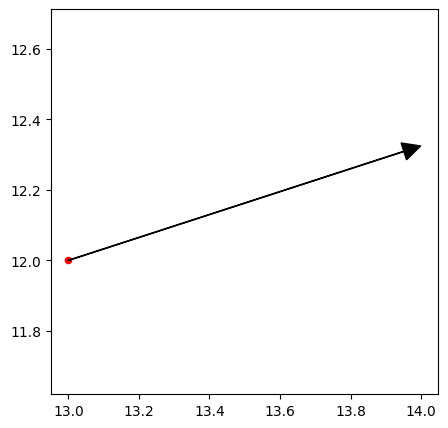

In [12]:
ax = plt.axes()
robot.draw(ax, with_orientation=True)
plt.show()

## Le capteur pour suivre sa propre trajectoire : l'odométrie

Jusqu'ici, nous avons vu la position et l'orientation du robot à différents instants. Voyons maintenant cela à travers le temps. Pour ce faire, on va simplement montrer 

(12,12) (13.0,12.0)
(13.0,12.0) (13.497260947684136,12.052264231633826)
(13.497260947684136,12.052264231633826) (13.790705227904278,12.114637738879154)
(13.790705227904278,12.114637738879154) (14.076022182792824,12.207342837191637)


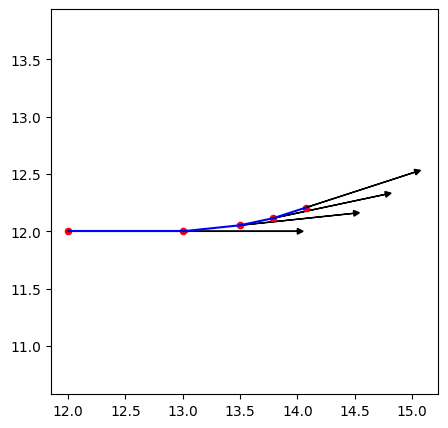

In [40]:
robot = reinit_robot()
ax = plt.axes()

positions = []  # Contient les positions d'arrivées
positions.append(robot.position)
robot.draw(ax, with_orientation=True)
positions.append(robot.move(10))
robot.draw(ax, with_orientation=True)
robot.turn(np.pi / 3)
positions.append(robot.move(5))
robot.draw(ax, with_orientation=True)
robot.turn(np.pi / 3)
positions.append(robot.move(3))
robot.draw(ax, with_orientation=True)
robot.turn(np.pi / 3)
positions.append(robot.move(3))
robot.draw(ax, with_orientation=True)
for position_1, position_2 in zip(positions[:-1], positions[1:]):
    print(position_1, position_2)
    # ax.axline((position_1.x, position_1.y), (position_2.x, position_2.y))
    # ax.plot(position_1.x, position_1.y, position_2.x, position_2.y, c='k')
    ax.plot([position_1.x, position_2.x], [position_1.y, position_2.y], color="blue")
# for position in positions:
#     ax.scatter([position.x], [position.y], color='red', marker='o', s=20)

plt.show()


In [24]:
positions

[Point(13.0, 12.0),
 Point(13.497260947684136, 12.052264231633826),
 Point(13.790705227904278, 12.114637738879154),
 Point(14.076022182792824, 12.207342837191637)]

Comment mesurer suivre la trajectoire du robot quand on est sur le robot ? Il suffit de 